In [1]:
import pandas as pd

In [2]:
d=pd.read_csv("Clean_Dataset.csv")
d

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [3]:
d.columns[d.isna().any()]

Index([], dtype='object')

In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x=d[["days_left"]]
y=d["price"]
x

,days_left
0,1
1,1
2,1
3,1
4,1
...,...
300148,49
300149,49
300150,49
300151,49


In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [9]:
x_train

,days_left
148417,6
36879,13
274531,44
166397,11
272722,5
...,...
119879,2
259178,7
131932,29
146867,39


In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
from sklearn.metrics import r2_score

In [12]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pre=lr.predict(x_test)
y_pre

array([18732.05482321, 18423.72553815, 18577.89018068, ...,
       20582.03053355, 18732.05482321, 24436.14659678], shape=(60031,))

In [14]:
lr.coef_

array([-154.16464253])

In [15]:
lr.intercept_

np.float64(24898.640524366725)

In [17]:
import numpy as np
c=np.array(1).reshape(-1,1)
s=lr.predict(c)
s

C:\Users\gavas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([24744.47588184])

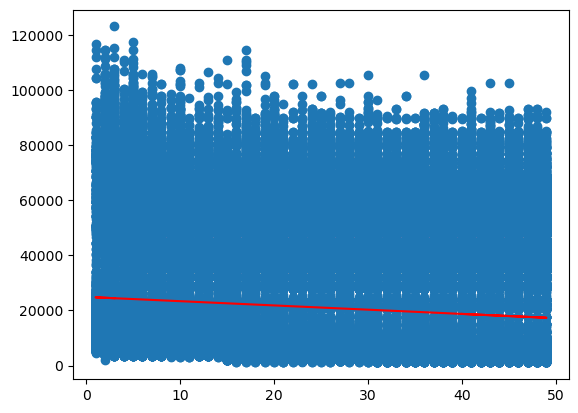

In [30]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x_test,y_pre,color="red")
plt.show()